# spVIPESmulti on PBMC CITE-seq — Vaccination Time-Course

This vignette demonstrates **spVIPESmulti** on a real-world CITE-seq dataset
from [Hao *et al.* (2021)](https://doi.org/10.1016/j.cell.2021.04.048),
available via [`scvi.data.pbmc_seurat_v4_cite_seq()`](https://docs.scvi-tools.org/en/1.4.1/api/reference/scvi.data.pbmc_seurat_v4_cite_seq.html).

**Dataset overview.** 161,764 peripheral blood mononuclear cells (PBMCs)
from 8 volunteers enrolled in an HIV vaccine trial, measured with CITE-seq
(simultaneous RNA + surface protein) at **three time points**: day 0
(baseline), day 3, and day 7 post-vaccination.

**What we showcase:**

| Feature | API |
|---|---|
| **3-group integration** (day 0 / day 3 / day 7) | `spVIPESmulti.data.prepare_adatas`, label-based PoE |
| **Shared latent** captures cell-type identity across time points | `get_latent_representation` → shared UMAP |
| **Private latents** capture time-point-specific variation | per-group private UMAP |
| **Training diagnostics** | ELBO training curve |
| **Gene loadings** | `get_loadings()` — top genes per latent factor |

> **Runtime:** The notebook subsamples to 2,000 cells per time point and
> 2,000 highly variable genes so it runs on a laptop CPU in ~10 minutes.
> For a full run, increase `N_PER_GROUP` and `N_HVG` and train on GPU.

## Requirements & Compatibility

> **scvi-tools ≥1.0 required.** spVIPESmulti targets scvi-tools 1.x and `lightning.pytorch` (was 0.20.x + `pytorch_lightning`). The deprecated `use_gpu=True` kwarg on `model.train(...)` has been **removed**; pass `accelerator="gpu", devices=1` (or `"auto"`) inside `**trainer_kwargs` instead. Minimum Python is 3.10. Several private scvi-tools modules removed in 1.x are now vendored under `spVIPESmulti.data`. See `CHANGELOG.md` for full details.

## 1. Environment

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import scvi
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import scipy.sparse as sp

import spVIPESmulti

np.random.seed(42)
torch.manual_seed(42)
sc.settings.set_figure_params(dpi=80, frameon=False)

print(f"spVIPESmulti   : {spVIPESmulti.__version__}")
print(f"scvi-tools: {scvi.__version__}")
print(f"scanpy    : {sc.__version__}")
print(f"torch     : {torch.__version__} (CUDA: {torch.cuda.is_available()})")

spVIPESmulti   : 0.3.0
scvi-tools: 1.4.2
scanpy    : 1.12.1
torch     : 2.11.0+cu128 (CUDA: True)


## 2. Load the PBMC CITE-seq dataset

[`scvi.data.pbmc_seurat_v4_cite_seq()`](https://docs.scvi-tools.org/en/1.4.1/api/reference/scvi.data.pbmc_seurat_v4_cite_seq.html)
downloads the Hao *et al.* (2021) CITE-seq dataset. It contains:

- **RNA** counts (raw UMI) in `adata.layers["counts"]` and log-normalised values in `adata.X`,
- **Protein** abundances (228 TotalSeq-A antibodies) in `adata.obsm["protein_counts"]`,
- Cell-type annotations, donor IDs, and time-point metadata in `adata.obs`.

The 8 donors were each sampled at **day 0, day 3, and day 7** following
vaccination — giving us a natural 3-group split for spVIPESmulti.

In [2]:
adata_full = scvi.data.pbmc_seurat_v4_cite_seq(save_path="./data/")
adata_full.obs_names_make_unique()

print("Shape         :", adata_full.shape)
print("Obs columns   :", list(adata_full.obs.columns[:15]))
print()
print(adata_full.obs.head(3))

INFO     Downloading file at ./data/pbmc_seurat_v4.h5ad                                                            
Downloading...: 100%|██████████| 1002579/1002579.0 [00:19<00:00, 52106.37it/s]
Shape         : (152094, 20729)
Obs columns   : ['nCount_ADT', 'nFeature_ADT', 'nCount_RNA', 'nFeature_RNA', 'orig.ident', 'lane', 'donor', 'time', 'celltype.l1', 'celltype.l2', 'celltype.l3', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'X_index']

                     nCount_ADT  nFeature_ADT  nCount_RNA  nFeature_RNA  \
L1_AAACCCAAGAAACTCA      7430.0           221     10823.0          2915   
L1_AAACCCAAGACATACA      5949.0           211      5864.0          1617   
L1_AAACCCACAACTGGTT      6547.0           217      5067.0          1381   

                    orig.ident lane donor time celltype.l1 celltype.l2  ...  \
L1_AAACCCAAGAAACTCA       P2_7   L1    P2    7        Mono   CD14 Mono  ...   
L1_AAACCCAAGACATACA       P1_7   L1    P1    7       CD4 T     CD4 TCM  ...   
L1_AAACCCACAACTGGTT    

## 3. Identify time points and assign groups

We extract the vaccination time point from the `orig.ident` (or batch)
column. Each donor–time combination forms a batch; the three time points
(day 0, day 3, day 7) define our **three groups** for spVIPESmulti.

This is a biologically motivated split: we expect shared cell-type
identity across all time points (captured by the **shared latent**),
while vaccination-induced changes should appear as time-point-specific
variation (captured by the **private latents**).

In [5]:
# Inspect available batch / donor information
print("Unique values in 'orig.ident':")
print(adata_full.obs["orig.ident"].value_counts())

Unique values in 'orig.ident':
orig.ident
P7_0    8430
P8_3    8289
P7_7    8151
P8_0    8135
P7_3    7639
P5_7    7276
P8_7    7165
P6_3    6972
P5_3    6359
P6_7    6333
P5_0    6322
P1_0    6243
P4_7    5871
P2_0    5791
P1_3    5758
P4_3    5686
P1_7    5645
P6_0    5606
P2_3    5562
P2_7    5365
P4_0    5221
P3_3    4861
P3_7    4847
P3_0    4567
Name: count, dtype: int64


In [6]:
# Extract the time point from the batch identifier
# The orig.ident column encodes donor and time, e.g. "P1_0", "P1_3", "P1_7"
# We parse the day from the last part after the underscore
def extract_time_point(ident):
    """Extract the day (0, 3, or 7) from the orig.ident string."""
    day = ident.split("_")[-1]
    return f"day_{day}"

adata_full.obs["time_point"] = adata_full.obs["orig.ident"].apply(extract_time_point)
adata_full.obs["time_point"] = adata_full.obs["time_point"].astype("category")

print("Cells per time point:")
print(adata_full.obs["time_point"].value_counts().sort_index())
print()

# Also check what cell-type annotations are available
if "celltype.l1" in adata_full.obs.columns:
    label_col = "celltype.l1"
elif "celltype.l2" in adata_full.obs.columns:
    label_col = "celltype.l2"
else:
    # Fall back: find the first column that looks like a cell-type annotation
    label_col = [c for c in adata_full.obs.columns if "cell" in c.lower() and "type" in c.lower()]
    label_col = label_col[0] if label_col else None

print(f"Cell-type label column: '{label_col}'")
if label_col:
    print(f"Number of cell types : {adata_full.obs[label_col].nunique()}")
    print(adata_full.obs[label_col].value_counts().head(10))

Cells per time point:
time_point
day_0    50315
day_3    51126
day_7    50653
Name: count, dtype: int64

Cell-type label column: 'celltype.l1'
Number of cell types : 8
celltype.l1
Mono       47217
CD4 T      40245
CD8 T      24399
NK         15384
B          13192
other T     5828
DC          3488
other       2341
Name: count, dtype: int64


## 4. Subsample and select highly variable genes

To keep runtime tractable on CPU we:

- subsample **2,000 cells per time point** (6,000 total),
- select the **top 2,000 highly variable genes**,
- and use `adata.layers["counts"]` (raw UMI counts) as input to spVIPESmulti.

For a full-scale run on GPU, increase `N_PER_GROUP` and `N_HVG`.

In [7]:
N_PER_GROUP = 5000   # cells per time point
N_HVG = 2000         # highly variable genes

# --- Subsample cells ---
rng = np.random.default_rng(42)
time_col = adata_full.obs["time_point"].values
pos_keep = []
for tp in sorted(adata_full.obs["time_point"].unique()):
    pos = np.where(time_col == tp)[0]
    pick = rng.choice(pos, size=min(N_PER_GROUP, len(pos)), replace=False)
    pos_keep.extend(pick)
pos_keep = np.array(sorted(pos_keep))
adata = adata_full[pos_keep].copy()
adata.obs_names_make_unique()

# --- Use raw counts as .X for spVIPESmulti ---
if "counts" in adata.layers:
    adata.X = adata.layers["counts"].copy()
    print("Using raw counts from adata.layers['counts']")

# --- Select top-N_HVG genes by variance ---
X = adata.X
if sp.issparse(X):
    gene_var = np.asarray(X.power(2).mean(axis=0)).flatten() - np.asarray(X.mean(axis=0)).flatten() ** 2
else:
    gene_var = np.var(X, axis=0)
top_gene_idx = np.argsort(gene_var)[::-1][:N_HVG]
adata = adata[:, top_gene_idx].copy()

print(f"After subsample + HVG : {adata.shape}")
print(f"Cells per time point  :")
print(adata.obs["time_point"].value_counts().sort_index())

After subsample + HVG : (15000, 2000)
Cells per time point  :
time_point
day_0    5000
day_3    5000
day_7    5000
Name: count, dtype: int64


## 5. Split into three groups and prepare for spVIPESmulti

We split the subsampled AnnData into three separate AnnData objects — one
per time point — and feed them into `spVIPESmulti.data.prepare_adatas()`.

This function concatenates the groups, adds group-level bookkeeping to
`adata.uns`, and appends group names to feature names (required for
spVIPESmulti' internal indexing).

In [8]:
# Split into per-time-point AnnData objects
time_points = sorted(adata.obs["time_point"].unique())
adatas_dict = {}
for tp in time_points:
    sub = adata[adata.obs["time_point"] == tp].copy()
    # Clean up — prepare_adatas doesn't need extra obsm/uns
    sub.uns = {}
    sub.obsm = {}
    sub.layers = {}
    adatas_dict[tp] = sub
    print(f"  {tp}: {sub.shape}")

# Concatenate with spVIPESmulti
adata_spv = spVIPESmulti.data.prepare_adatas(adatas_dict)

print(f"\nConcatenated AnnData: {adata_spv.shape}")
print(f"Groups             : {list(adata_spv.uns['groups_mapping'].values())}")
print(f"Group sizes        : {[len(g) for g in adata_spv.uns['groups_obs_indices']]}")

  day_0: (5000, 2000)
  day_3: (5000, 2000)
  day_7: (5000, 2000)

Concatenated AnnData: (15000, 6000)
Groups             : ['day_0', 'day_3', 'day_7']
Group sizes        : [5000, 5000, 5000]


## 6. Set up the model — label-based PoE

With **three groups**, we use the **label-based Product of Experts (PoE)**
strategy. This requires a cell-type label column in `adata.obs`.
`setup_anndata` will match cells across groups that share the same label
and combine their encoder outputs through the PoE to produce the shared
latent representation.

Cell types present in one time point but absent in another are handled
gracefully — the missing group contributes an uninformative prior N(0, I).

In [9]:
spVIPESmulti.model.spVIPESmulti.setup_anndata(
    adata_spv,
    groups_key="groups",
    label_key=label_col,
)

=== spVIPESmulti AnnData Setup ===
Setting up with groups_key: 'groups'
✓ Labels: Using 'celltype.l1' from adata.obs

--- Product of Experts (PoE) Configuration ---
🎯 Will use: Label-based PoE


## 7. Instantiate and train the model

We configure the model with:

- **`n_dimensions_shared=15`**: the shared latent captures cell-type identity common across all three time points.
- **`n_dimensions_private=8`**: each group gets its own private latent to capture time-point-specific variation.
- **`n_hidden=128`**: width of the hidden layer in encoders and decoders.
- Training uses KL warmup over the first 30 epochs to stabilise early training.

In [11]:
# Model hyperparameters
N_SHARED   = 15
N_PRIVATE  = 8
N_HIDDEN   = 128
DROPOUT    = 0.1
MAX_EPOCHS = 50
BATCH_SIZE = 512
KL_WARMUP  = 20

model = spVIPESmulti.model.spVIPESmulti(
    adata_spv,
    n_hidden=N_HIDDEN,
    n_dimensions_shared=N_SHARED,
    n_dimensions_private=N_PRIVATE,
    dropout_rate=DROPOUT,
)
print(model)

INFO     spVIPESmulti: The model has been initialized                                                                   


spVIPESmulti Model with the following params: 
n_hidden: 128, n_dimensions_shared: 15, n_dimensions_private: 8, dropout_rate: 0.1, multimodal: No, nf_prior: No
Training status: Not Trained

In [12]:
# Get group indices for training
group_indices_list = [
    np.where(adata_spv.obs["groups"] == group)[0]
    for group in adata_spv.obs["groups"].unique()
]
print("Group sizes:", [len(g) for g in group_indices_list])

# Train
model.train(
    group_indices_list,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    train_size=0.9,
    early_stopping=False,
    n_epochs_kl_warmup=KL_WARMUP,
)

Group sizes: [5000, 5000, 5000]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 50/50: 100%|██████████| 50/50 [01:40<00:00,  1.99s/it, v_num=1, train_loss=5.98e+3]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 50/50: 100%|██████████| 50/50 [01:40<00:00,  2.02s/it, v_num=1, train_loss=5.98e+3]


## 8. Training diagnostics

We plot the ELBO training loss to verify that the model converged.

TypeError: 'NoneType' object is not subscriptable

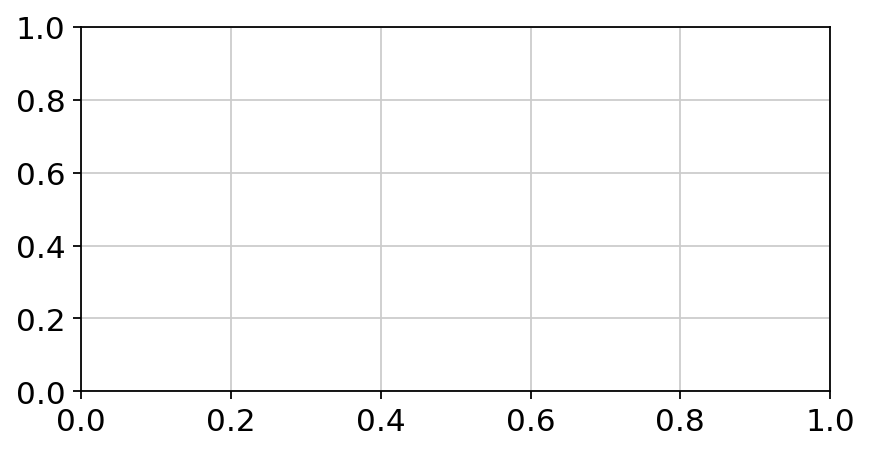

In [13]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(model.history["elbo_train"]["elbo_train"], label="ELBO (train)")
if "elbo_validation" in model.history:
    ax.plot(model.history["elbo_validation"]["elbo_validation"], label="ELBO (val)")
ax.set_xlabel("Epoch")
ax.set_ylabel("ELBO")
ax.set_title("spVIPESmulti training curve")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

## 9. Extract latent representations

spVIPESmulti returns three sets of latent variables:

- **Shared latent** (one per cell): captures variation common to all time points — primarily cell-type identity.
- **Private latents** (one per group): capture time-point-specific variation — vaccination-induced changes.

The `_reordered` variants are aligned back to the original cell order in `adata_spv`.

In [14]:
latents = model.get_latent_representation(group_indices_list, batch_size=BATCH_SIZE)

print("Latent keys:", list(latents.keys()))
for g, tp in enumerate(time_points):
    print(f"  {tp}  shared: {latents['shared_reordered'][g].shape}  "
          f"private: {latents['private_reordered'][g].shape}")

Latent keys: ['shared', 'private', 'shared_reordered', 'private_reordered']
  day_0  shared: (5000, 15)  private: (5000, 8)
  day_3  shared: (5000, 15)  private: (5000, 8)
  day_7  shared: (5000, 15)  private: (5000, 8)


In [ ]:
spVIPESmulti.utils.store_latents(adata_spv, latents, group_indices_list)


## 10. Visualise the shared latent space

The shared latent should integrate cells across time points while
preserving cell-type identity. We compute UMAP on the shared embedding
and colour by:

1. **Cell type** — clusters should reflect biological identity.
2. **Time point** — groups should be well-mixed within each cluster, indicating successful integration.

In [ ]:
spVIPESmulti.utils.compute_shared_umap(adata_spv, umap_key="X_umap_shared")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc.pl.embedding(
    adata_spv, basis="X_umap_shared", color=label_col,
    ax=axes[0], show=False, title="Shared latent — cell types",
    legend_loc="on data", legend_fontsize=6, size=8,
)
sc.pl.embedding(
    adata_spv, basis="X_umap_shared", color="time_point",
    ax=axes[1], show=False, title="Shared latent — time points",
    palette="Set2", size=8,
)

sns.despine()
plt.tight_layout()
plt.show()

## 10b. Disentanglement objective

spVIPESmulti supports an optional **disentanglement objective** that explicitly
enforces:

* `z_shared` encodes cell-type biology but **not** vaccination time point
* `z_private` encodes time-point-specific variation but **not** cell-type biology

Across vaccination time points this should help isolate shared cell-type
identity from day-specific expression shifts. Enabled via
`disentangle_preset='full'`. Note that `model.get_loadings()` is also
available on the disentanglement-enabled model and is typically more
interpretable when biology is concentrated in `z_shared`. See
`disentangle_ablation.ipynb` for a per-component ablation.


In [22]:
# Split into per-time-point AnnData objects
time_points = sorted(adata.obs["time_point"].unique())
adatas_dict = {}
for tp in time_points:
    sub = adata[adata.obs["time_point"] == tp].copy()
    # Clean up — prepare_adatas doesn't need extra obsm/uns
    sub.uns = {}
    sub.obsm = {}
    sub.layers = {}
    adatas_dict[tp] = sub
    print(f"  {tp}: {sub.shape}")

# Concatenate with spVIPESmulti
adata_spv = spVIPESmulti.data.prepare_adatas(adatas_dict)

spVIPESmulti.model.spVIPESmulti.setup_anndata(
    adata_spv,
    groups_key="groups",
    label_key=label_col,
)

  day_0: (5000, 2000)
  day_3: (5000, 2000)
  day_7: (5000, 2000)
=== spVIPESmulti AnnData Setup ===
Setting up with groups_key: 'groups'
✓ Labels: Using 'celltype.l1' from adata.obs

--- Product of Experts (PoE) Configuration ---
🎯 Will use: Label-based PoE


In [23]:
model_dis = spVIPESmulti.model.spVIPESmulti(
    adata_spv,
    n_hidden=N_HIDDEN,
    n_dimensions_shared=N_SHARED,
    n_dimensions_private=N_PRIVATE,
    dropout_rate=DROPOUT,
    disentangle_preset="full",
)
model_dis.train(
    group_indices_list,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    train_size=0.9,
    early_stopping=False,
    n_epochs_kl_warmup=KL_WARMUP,
)


INFO     spVIPESmulti: The model has been initialized                                                                   


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 50/50: 100%|██████████| 50/50 [01:42<00:00,  2.03s/it, v_num=1, train_loss=6.02e+3]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 50/50: 100%|██████████| 50/50 [01:42<00:00,  2.06s/it, v_num=1, train_loss=6.02e+3]


In [ ]:
latents_dis = model_dis.get_latent_representation(group_indices_list, batch_size=BATCH_SIZE)
adata_spv.obsm["X_spVIPESmulti_shared_dis"] = np.vstack(
    [latents_dis["shared_reordered"][g] for g in range(len(time_points))]
)
spVIPESmulti.utils.compute_shared_umap(
    adata_spv, obsm_key="X_spVIPESmulti_shared_dis", umap_key="X_umap_shared_dis"
)


In [27]:
adata_spv

AnnData object with n_obs × n_vars = 15000 × 6000
    obs: 'nCount_ADT', 'nFeature_ADT', 'nCount_RNA', 'nFeature_RNA', 'orig.ident', 'lane', 'donor', 'time', 'celltype.l1', 'celltype.l2', 'celltype.l3', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'X_index', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Protein log library size', 'Number proteins detected', 'RNA log library size', 'time_point', 'groups', 'indices', '_scvi_batch', '_scvi_groups', '_scvi_labels', '_scvi_indices'
    uns: 'groups_var_indices', 'groups_obs_indices', 'groups_obs_names', 'groups_obs', 'groups_lengths', 'groups_var_names', 'groups_mapping', '_scvi_uuid', '_scvi_manager_uuid', 'spvipesmulti_shared_dis', 'umap'
    obsm: 'X_spVIPESmulti_shared_dis', 'X_umap', 'X_umap_shared_dis'
    obsp: 'spvipesmulti_shared_dis_distances', 'spvipesmulti_shared_dis_connectivities'

### Compare baseline vs `disentangle_preset='full'`

Top row: shared latent coloured by **cell type** (label preservation).
Bottom row: shared latent coloured by **time point** (group mixing).
Disentanglement should mix time points more thoroughly while preserving
cell-type clusters.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for col, (basis, title) in enumerate([
    ("X_umap_shared", "baseline"),
    ("X_umap_shared_dis", "disentangle=full"),
]):
    sc.pl.embedding(adata_spv, basis=basis, color=label_col,
                    ax=axes[0, col], show=False,
                    title=f"shared / {title} — cell type",
                    legend_loc="on data", legend_fontsize=6, size=8)
    sc.pl.embedding(adata_spv, basis=basis, color="time_point",
                    ax=axes[1, col], show=False,
                    title=f"shared / {title} — time point", size=8)
plt.tight_layout(); plt.show()


In [ ]:
groups_arr = adata_spv.obs["time_point"].values
labels_arr = adata_spv.obs[label_col].values
pd.DataFrame({
    'group_mixing_shared (higher=better)': [
        spVIPESmulti.metrics.kbet(adata_spv.obsm['X_spVIPESmulti_shared'], groups_arr),
        spVIPESmulti.metrics.kbet(adata_spv.obsm['X_spVIPESmulti_shared_dis'], groups_arr),
    ],
    'label_purity_shared (higher=better)': [
        spVIPESmulti.metrics.knn_purity(adata_spv.obsm['X_spVIPESmulti_shared'], labels_arr),
        spVIPESmulti.metrics.knn_purity(adata_spv.obsm['X_spVIPESmulti_shared_dis'], labels_arr),
    ],
}, index=['baseline', 'disentangle=full'])


## 11. Visualise the private latent spaces

Each time point has its own private latent space. The private latent should
capture variation **specific** to that time point — e.g., vaccination-induced
transcriptional changes at day 3 or day 7 that are not present at baseline.

Ideally, private spaces should:
- Show internal structure reflecting time-point-specific biology.
- **Not** separate cells by cell type (that information belongs in the shared space).

In [ ]:
# Build per-group sub-AnnDatas with private embeddings
group_adatas = {}
for g, tp in enumerate(time_points):
    mask = adata_spv.obs["groups"] == tp
    sub = adata_spv[mask].copy()
    sub.obsm["X_spVIPESmulti_private"] = latents["private_reordered"][g]
    group_adatas[tp] = sub

spVIPESmulti.utils.compute_private_umaps(group_adatas, umap_key="X_umap_private")

# Plot private latents coloured by cell type (should show little structure)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, tp in zip(axes, time_points):
    sc.pl.embedding(
        group_adatas[tp], basis="X_umap_private", color=label_col,
        ax=ax, show=False, title=f"Private latent — {tp}", size=14,
    )
sns.despine()
plt.tight_layout()
plt.show()

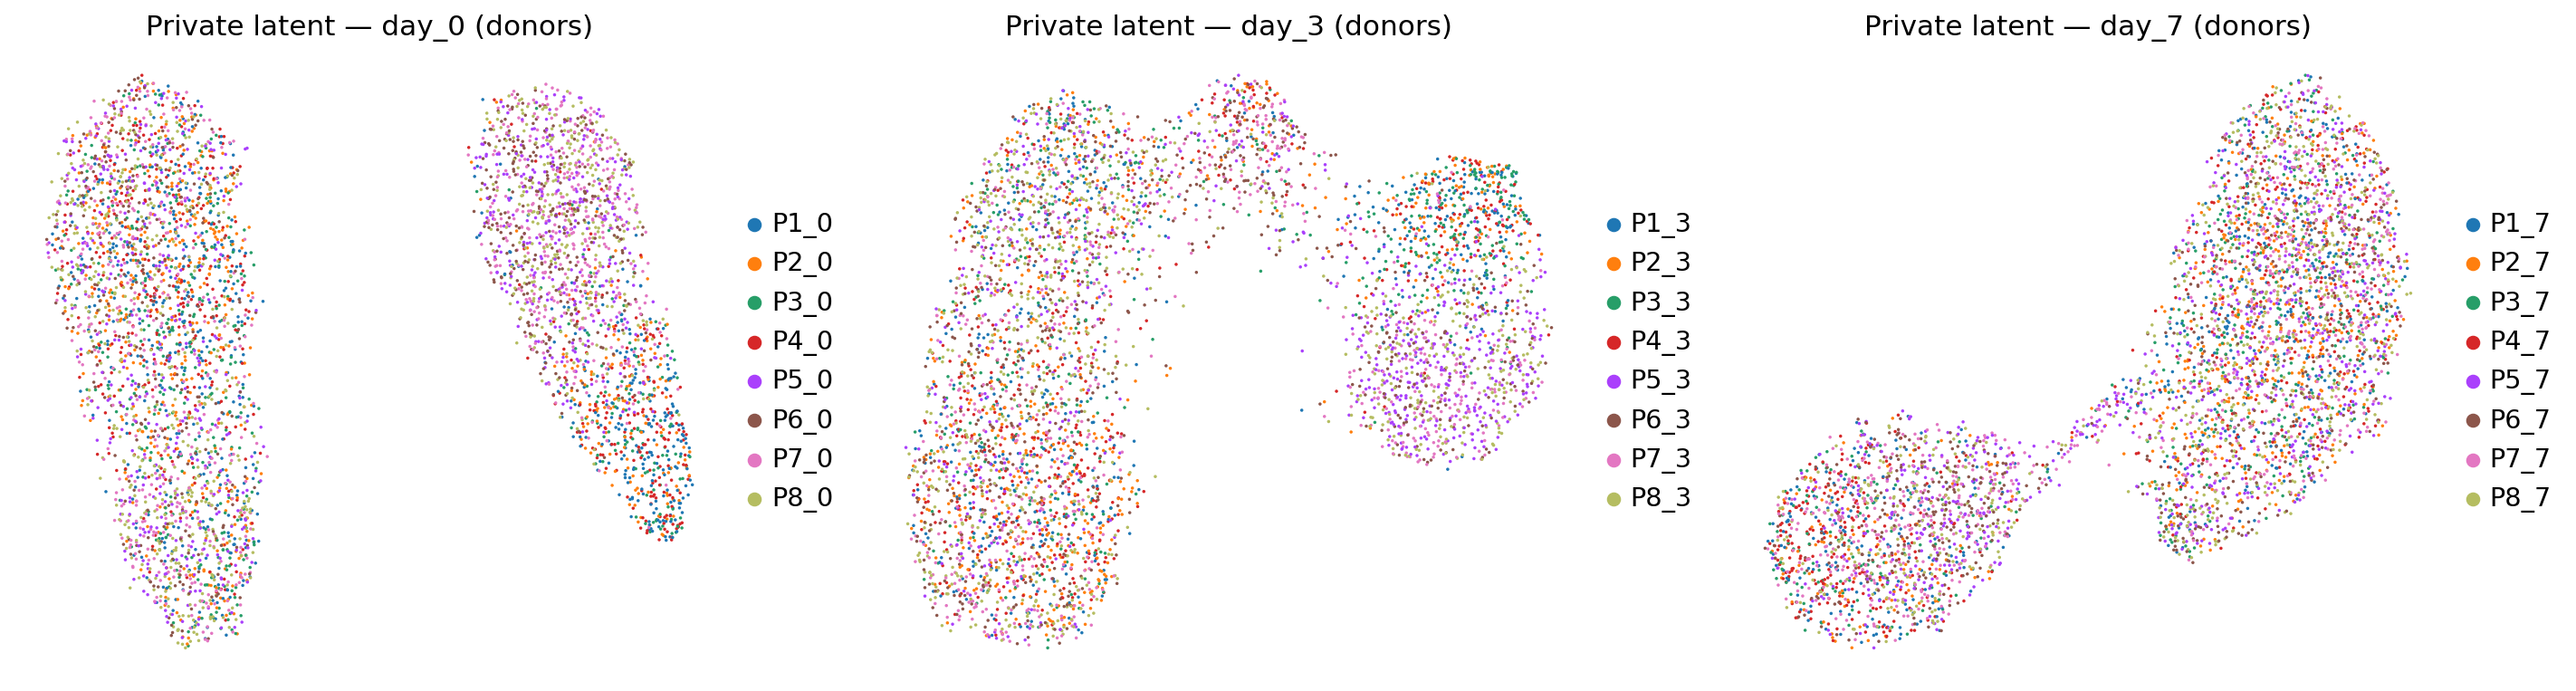

In [31]:
# Plot private latents coloured by donor to see if private space captures donor effects
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, tp in zip(axes, time_points):
    sc.pl.embedding(
        group_adatas[tp], basis="X_umap_private", color="orig.ident",
        ax=ax, show=False, title=f"Private latent — {tp} (donors)",
        size=10,
    )
sns.despine()
plt.tight_layout()
plt.show()

## 12. Gene loadings — which genes drive each latent factor?

spVIPESmulti uses a linear decoder, so we can extract per-gene weights (loadings)
linking each latent dimension to gene expression. This is useful for
interpreting what biological signals each latent factor captures.

We inspect the top genes per shared and private latent dimension.

In [34]:
loadings = model.get_loadings()

print("Loading keys (group, latent_type):")
for key in loadings:
    print(f"  {key}: {loadings[key].shape}")

Loading keys (group, latent_type):
  (0, 'private'): (2000, 8)
  (0, 'shared'): (2000, 15)
  (1, 'private'): (2000, 8)
  (1, 'shared'): (2000, 15)
  (2, 'private'): (2000, 8)
  (2, 'shared'): (2000, 15)


In [ ]:
# Top 5 genes per shared latent dimension (from the first group's decoder)
first_group_key = [k for k in loadings if "shared" in k[1]][0]
shared_loadings = loadings[first_group_key]

print(f"Top 5 genes per shared dimension ({first_group_key[0]} decoder):\n")
top_df = spVIPESmulti.utils.get_top_genes(shared_loadings, n_top=5, signed=False)
print(top_df[["dim", "top_genes"]].to_string(index=False))


In [41]:
# Top 25 genes per private latent dimension (from the first group's decoder)
private_loadings = loadings[1, "private"]

print(f"Top 25 genes per private dimension ({first_group_key[0]} decoder):\n")
top_genes = private_loadings.apply(lambda col: col.abs().nlargest(25).index.tolist())
print(top_genes.to_string())

Top 25 genes per private dimension (0 decoder):

      Z_private_0     Z_private_1     Z_private_2     Z_private_3   Z_private_4     Z_private_5    Z_private_6      Z_private_7
0     day_3_TAF1D    day_3_HIGD2A    day_3_TRIM38    day_3_EIF2S2    day_3_CRBN     day_3_CREB5     day_3_ETS1    day_3_ANAPC11
1      day_3_DSTN     day_3_RPL26     day_3_KRT10   day_3_FAM204A   day_3_RAB8B    day_3_OSBPL8  day_3_ATP5F1C     day_3_TRIP12
2     day_3_MACF1     day_3_SEPT9    day_3_SNRPD2       day_3_CSK   day_3_RPL36      day_3_RPS2      day_3_JUN      day_3_SPCS1
3     day_3_ZMAT2      day_3_PTMA      day_3_CIR1      day_3_HM13   day_3_PFDN2     day_3_ALDH2    day_3_RPLP2   day_3_HIST1H4C
4      day_3_TUFM     day_3_ABCF1    day_3_RNF166    day_3_NDUFS6   day_3_APEX1      day_3_CTSA    day_3_KPNB1        day_3_SSB
5    day_3_MALAT1   day_3_IFI27L2      day_3_KLF4     day_3_BNIP2    day_3_PJA2    day_3_MINOS1   day_3_ARID4B     day_3_UBE2L6
6      day_3_SAT2     day_3_TMOD3     day_3_WIPF1     d

In [73]:
group_adatas["day_3"].obs["private4"] = group_adatas["day_3"].obsm["X_spVIPESmulti_private"][:,4]

In [80]:
group_adatas["day_3"]

AnnData object with n_obs × n_vars = 5000 × 6000
    obs: 'nCount_ADT', 'nFeature_ADT', 'nCount_RNA', 'nFeature_RNA', 'orig.ident', 'lane', 'donor', 'time', 'celltype.l1', 'celltype.l2', 'celltype.l3', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'X_index', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Protein log library size', 'Number proteins detected', 'RNA log library size', 'time_point', 'groups', 'indices', '_scvi_batch', '_scvi_groups', '_scvi_labels', '_scvi_indices', 'private1', 'private2', 'private3', 'private4'
    uns: 'groups_var_indices', 'groups_obs_indices', 'groups_obs_names', 'groups_obs', 'groups_lengths', 'groups_var_names', 'groups_mapping', '_scvi_uuid', '_scvi_manager_uuid', 'spvipesmulti_shared_dis', 'umap', 'celltype.l1_colors', 'time_point_colors', 'spvipesmulti_private', 'orig.ident_colors', 'time_colors', 'donor_colors', 'groups_colors', 'lane_colors', 'celltype.l2_colors'
    obsm: 'X_spVIPESmulti_shared_dis', 'X_umap', 'X_umap_shared_dis', 'X_spVIPESmult

In [79]:
group_adatas["day_3"].obs.columns

Index(['nCount_ADT', 'nFeature_ADT', 'nCount_RNA', 'nFeature_RNA',
       'orig.ident', 'lane', 'donor', 'time', 'celltype.l1', 'celltype.l2',
       'celltype.l3', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'X_index',
       'total_counts', 'total_counts_mt', 'pct_counts_mt',
       'Protein log library size', 'Number proteins detected',
       'RNA log library size', 'time_point', 'groups', 'indices',
       '_scvi_batch', '_scvi_groups', '_scvi_labels', '_scvi_indices',
       'private1', 'private2', 'private3', 'private4'],
      dtype='object')

In [94]:
from matplotlib.pyplot import rc_context

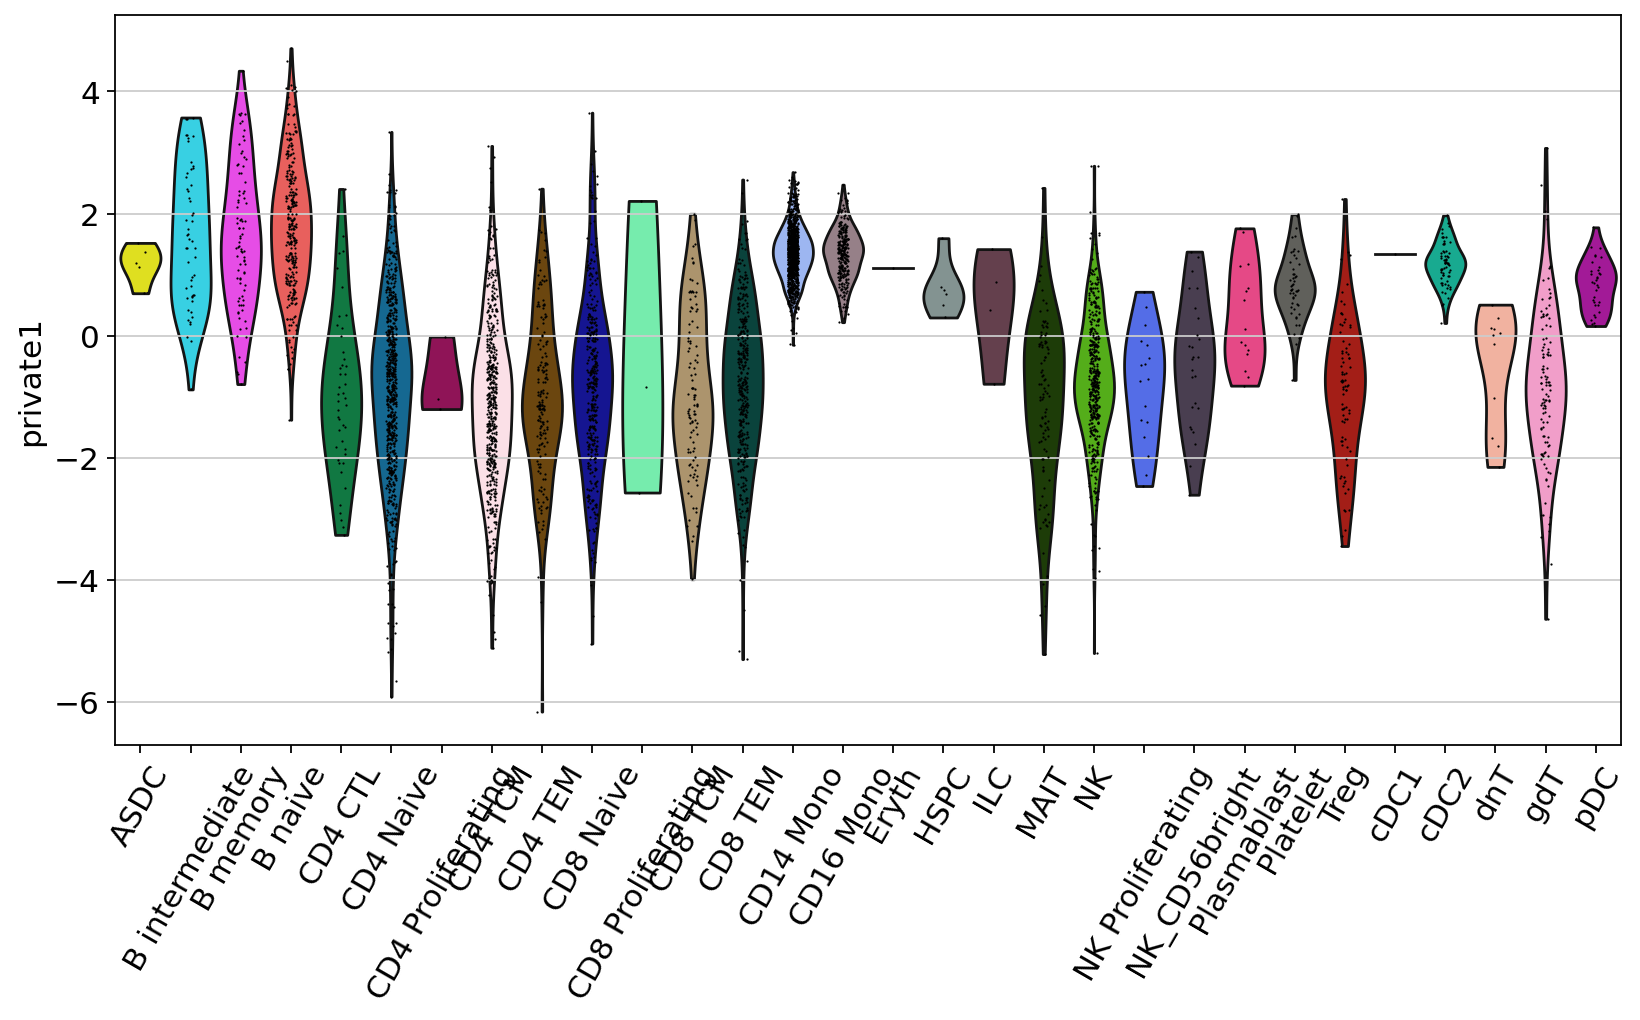

In [100]:
with rc_context({"figure.figsize": (10, 6)}):
    sc.pl.violin(group_adatas["day_3"], "private1", groupby="celltype.l2", show=True, rotation=60)

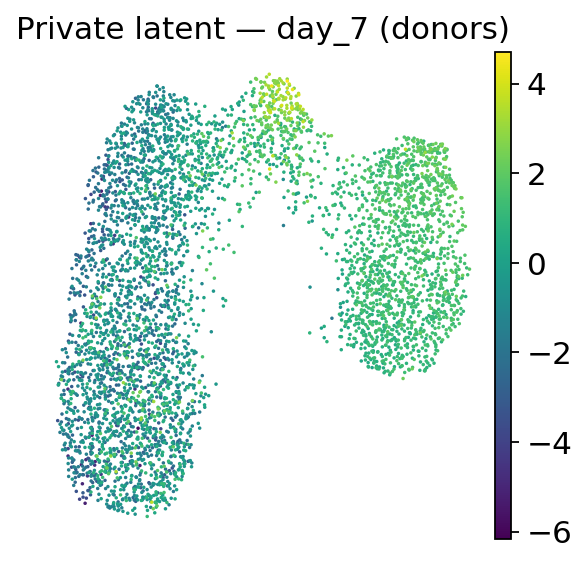

In [ ]:
sc.pl.embedding(
        group_adatas["day_3"], basis="X_umap_private", color="private1",
        show=True, title=f"Private latent — {tp} (donors)",
        size=10)

In [ ]:
ax = spVIPESmulti.pl.heatmap_loadings(shared_loadings, n_top=10)
ax.set_title(f"Shared decoder loadings — {first_group_key[0]}")
plt.tight_layout()
plt.show()


## 13. Quantitative evaluation

We evaluate the shared latent space with two complementary metrics:

- **Biological conservation (ARI):** Adjusted Rand Index between Leiden
  clusters on the shared embedding and ground-truth cell-type labels.
  Higher is better — the embedding preserves cell identity.
- **Batch mixing (entropy):** Normalised entropy of the time-point
  distribution inside k-nearest-neighbour balls. Higher is better (1.0 =
  perfect mixing across time points).

A successful shared latent achieves **high ARI and high batch mixing
simultaneously**.

In [ ]:
rep = adata_spv.obsm["X_spVIPESmulti_shared"]
ari = spVIPESmulti.metrics.leiden_ari(rep, adata_spv.obs[label_col].values)
mix = spVIPESmulti.metrics.ilisi(rep, adata_spv.obs["time_point"].values, k=30)

results_df = pd.DataFrame([{
    "ARI (cell types)": round(ari, 3),
    "Batch mixing (time points)": round(mix, 3),
}], index=["spVIPESmulti shared"])

print(results_df.to_string())


NameError: name 'results_df' is not defined

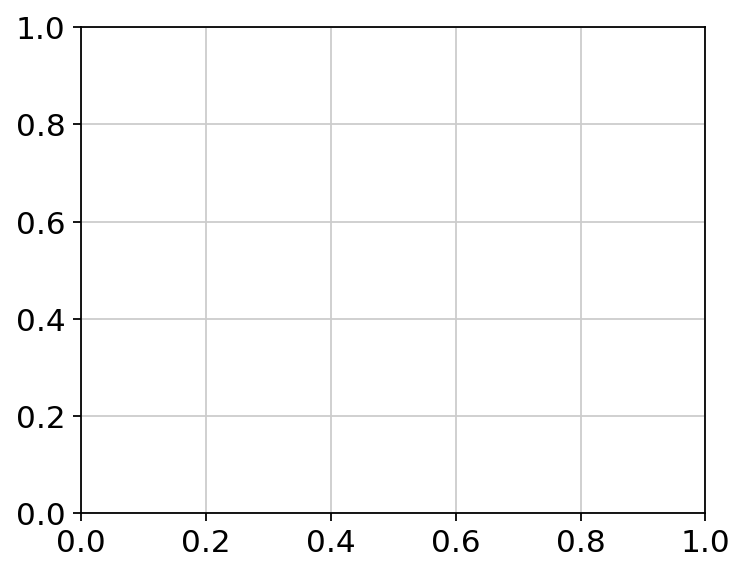

In [38]:
fig, ax = plt.subplots(figsize=(5, 4))
x = np.arange(len(results_df.columns))
width = 0.5
bars = ax.bar(x, results_df.values[0], width, color=["#4C72B0", "#55A868"])
ax.set_xticks(x)
ax.set_xticklabels(results_df.columns, fontsize=10)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Shared latent quality")
for bar, val in zip(bars, results_df.values[0]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

## 14. Optional: multimodal mode

The PBMC CITE-seq dataset ships RNA in `.X` and protein counts in `.obsm["protein_counts"]`. The single-modality flow above treats only the RNA. Below we exercise the multimodal entry point — `prepare_multimodal_adatas` + per-(group, modality) encoders + two-level PoE — on the same data as a forward pointer to [`multimodal_nf_tutorial.ipynb`](multimodal_nf_tutorial.ipynb), which covers `modality_loss_weights`, `use_jeffreys_integ`, and multimodal disentanglement in depth.

We use a much smaller subsample (500 cells / time point, 5 epochs) so the appendix adds only ~1–2 minutes of runtime.

In [ ]:
import anndata as ad

PROT_KEY = next(k for k in ("protein_counts", "protein_expression") if k in adata_full.obsm)
print("Protein modality stored under obsm[", repr(PROT_KEY), "]")

N_PER_GROUP_MM = 500
rng_mm = np.random.default_rng(0)
tp_col = adata_full.obs["time_point"].values
pos_mm = []
for tp in sorted(adata_full.obs["time_point"].unique()):
    pos = np.where(tp_col == tp)[0]
    pos_mm.extend(rng_mm.choice(pos, size=min(N_PER_GROUP_MM, len(pos)), replace=False))
pos_mm = np.array(sorted(pos_mm))
adata_mm = adata_full[pos_mm].copy()
adata_mm.obs_names_make_unique()
if "counts" in adata_mm.layers:
    adata_mm.X = adata_mm.layers["counts"].copy()

print("Subsample shape:", adata_mm.shape, "|", PROT_KEY, "shape:", adata_mm.obsm[PROT_KEY].shape)

In [ ]:
# Build per-(group, modality) AnnData dict
adatas_dict_mm = {}
time_points_mm = sorted(adata_mm.obs["time_point"].unique())
for tp in time_points_mm:
    sub = adata_mm[adata_mm.obs["time_point"] == tp].copy()
    rna = ad.AnnData(X=sub.X, obs=sub.obs.copy(), var=sub.var.copy())
    prot_arr = sub.obsm[PROT_KEY]
    if hasattr(prot_arr, "values"):
        prot_var = pd.DataFrame(index=list(prot_arr.columns))
        prot_X = prot_arr.values.astype(np.float32)
    else:
        prot_var = pd.DataFrame(index=[f"protein_{i}" for i in range(prot_arr.shape[1])])
        prot_X = np.asarray(prot_arr, dtype=np.float32)
    prot = ad.AnnData(X=prot_X, obs=sub.obs.copy(), var=prot_var)
    adatas_dict_mm[str(tp)] = {"rna": rna, "protein": prot}

mdata_mm = spVIPESmulti.data.prepare_multimodal_adatas(
    adatas_dict_mm,
    modality_likelihoods={"rna": "nb", "protein": "nb"},
)
print("is_multimodal:", mdata_mm.uns["is_multimodal"])
print("modality_names:", mdata_mm.uns["modality_names"])
print("modality lengths per group:", mdata_mm.uns["groups_modality_lengths"])
pd.DataFrame(mdata_mm.uns["groups_modality_masks"]).T

In [ ]:
spVIPESmulti.model.spVIPESmulti.setup_anndata(
    mdata_mm,
    groups_key="groups",
    label_key="cell_types" if "cell_types" in mdata_mm.obs.columns else None,
    modality_likelihoods={"rna": "nb", "protein": "nb"},
)

torch.manual_seed(0)
np.random.seed(0)
model_mm = spVIPESmulti.model.spVIPESmulti(
    mdata_mm,
    n_hidden=64,
    n_dimensions_shared=10,
    n_dimensions_private=4,
    dropout_rate=0.1,
)

In [ ]:
group_indices_list_mm = [list(map(int, g)) for g in mdata_mm.uns["groups_obs_indices"]]
model_mm.train(
    group_indices_list=group_indices_list_mm,
    max_epochs=5,
    batch_size=128,
    train_size=0.9,
    early_stopping=False,
    n_epochs_kl_warmup=3,
)

latents_mm = model_mm.get_latent_representation(
    group_indices_list=group_indices_list_mm,
    batch_size=128,
)
print("Returned latent keys:", sorted(latents_mm.keys()))
print("Per-(group, modality) private latent keys:", sorted(latents_mm["private_multimodal"].keys()))

The keys above (`shared`, `shared_reordered`, `private`, `private_reordered`, **plus** `private_multimodal` and `private_multimodal_reordered`) are the multimodal-specific output. For a quantitative comparison of Gaussian / NSF / Jeffreys / disentangle on a 3-group multimodal dataset, see [`multimodal_nf_tutorial.ipynb`](multimodal_nf_tutorial.ipynb).

## 15. Summary

In this vignette we demonstrated spVIPESmulti on the Hao *et al.* (2021)
PBMC CITE-seq vaccination time-course dataset:

1. **Three-group integration** — cells from day 0, day 3, and day 7
   were integrated using the label-based Product of Experts.
2. **Shared latent space** — captures cell-type identity while mixing
   cells from all three time points, as confirmed by both UMAP
   visualisation and quantitative ARI / batch-mixing scores.
3. **Private latent spaces** — one per time point, designed to capture
   time-point-specific variation (vaccination response) without
   recapitulating shared cell-type structure.
4. **Gene loadings** — the linear decoder weights reveal which genes
   drive each latent dimension, aiding biological interpretation.

### Next steps

- **Multimodal integration:** This dataset contains protein measurements
  alongside RNA. See the [multimodal tutorial](multimodal_nf_tutorial.ipynb)
  for how to use `prepare_multimodal_adatas` with both RNA and protein
  modalities.
- **Normalizing flow priors:** Replace the standard Gaussian prior with
  Neural Spline Flows (`use_nf_prior=True`) for more expressive latent
  distributions.
- **Full-scale run:** Increase `N_PER_GROUP` and `N_HVG`, train for more
  epochs on GPU, and use `early_stopping=True` for optimal performance.

### References

- Hao, Y. *et al.* (2021). *Integrated analysis of multimodal single-cell
  data.* Cell 184, 3573-3587.
- Novella-Rausell, C., Peters, D.J.M., & Mahfouz, A. (2023).
  *Integrative learning of disentangled representations in multi-view
  single-cell data.*